In [1]:
import os
import h5py
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt


In [3]:

# -----------------------------
# Load data
# -----------------------------
file = 'mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat'
screen_size = (600, 800)
whichRun = 1  # MATLAB-style indexing

with h5py.File(file, 'r') as f:
    print("Keys in the .mat file:", list(f.keys()))
    frozen_images = np.array(f['frozenImages']).transpose((0, 2, 1))
    frozen_fixations = np.array(f['frozenfixations']) # 
    running_images = np.array(f['runningImages']).transpose((0, 2, 1))
    running_fixations = np.array(f['runningfixations']) # Ntrials x Nframes x 3 ([image_idx, x, y])

print("frozen_images:", frozen_images.shape)
print("frozen_fixations:", frozen_fixations.shape)
print("running_images:", running_images.shape)
print("running_fixations:", running_fixations.shape)

global_min = min(frozen_images.min(), running_images.min())
global_max = max(frozen_images.max(), running_images.max())
scale = global_max - global_min + 1e-8

frozen_images = (frozen_images - global_min) / scale
running_images = (running_images - global_min) / scale


Keys in the .mat file: ['#refs#', 'foffsets', 'fonsets', 'frozenImages', 'frozenbin', 'frozenfixations', 'options', 'runningImages', 'runningbin', 'runningfixations', 'spikesbin', 'spiketimes', 'stimPara']
frozen_images: (25, 1024, 1532)
frozen_fixations: (1875, 3)
running_images: (300, 1024, 1532)
running_fixations: (31, 2625, 3)


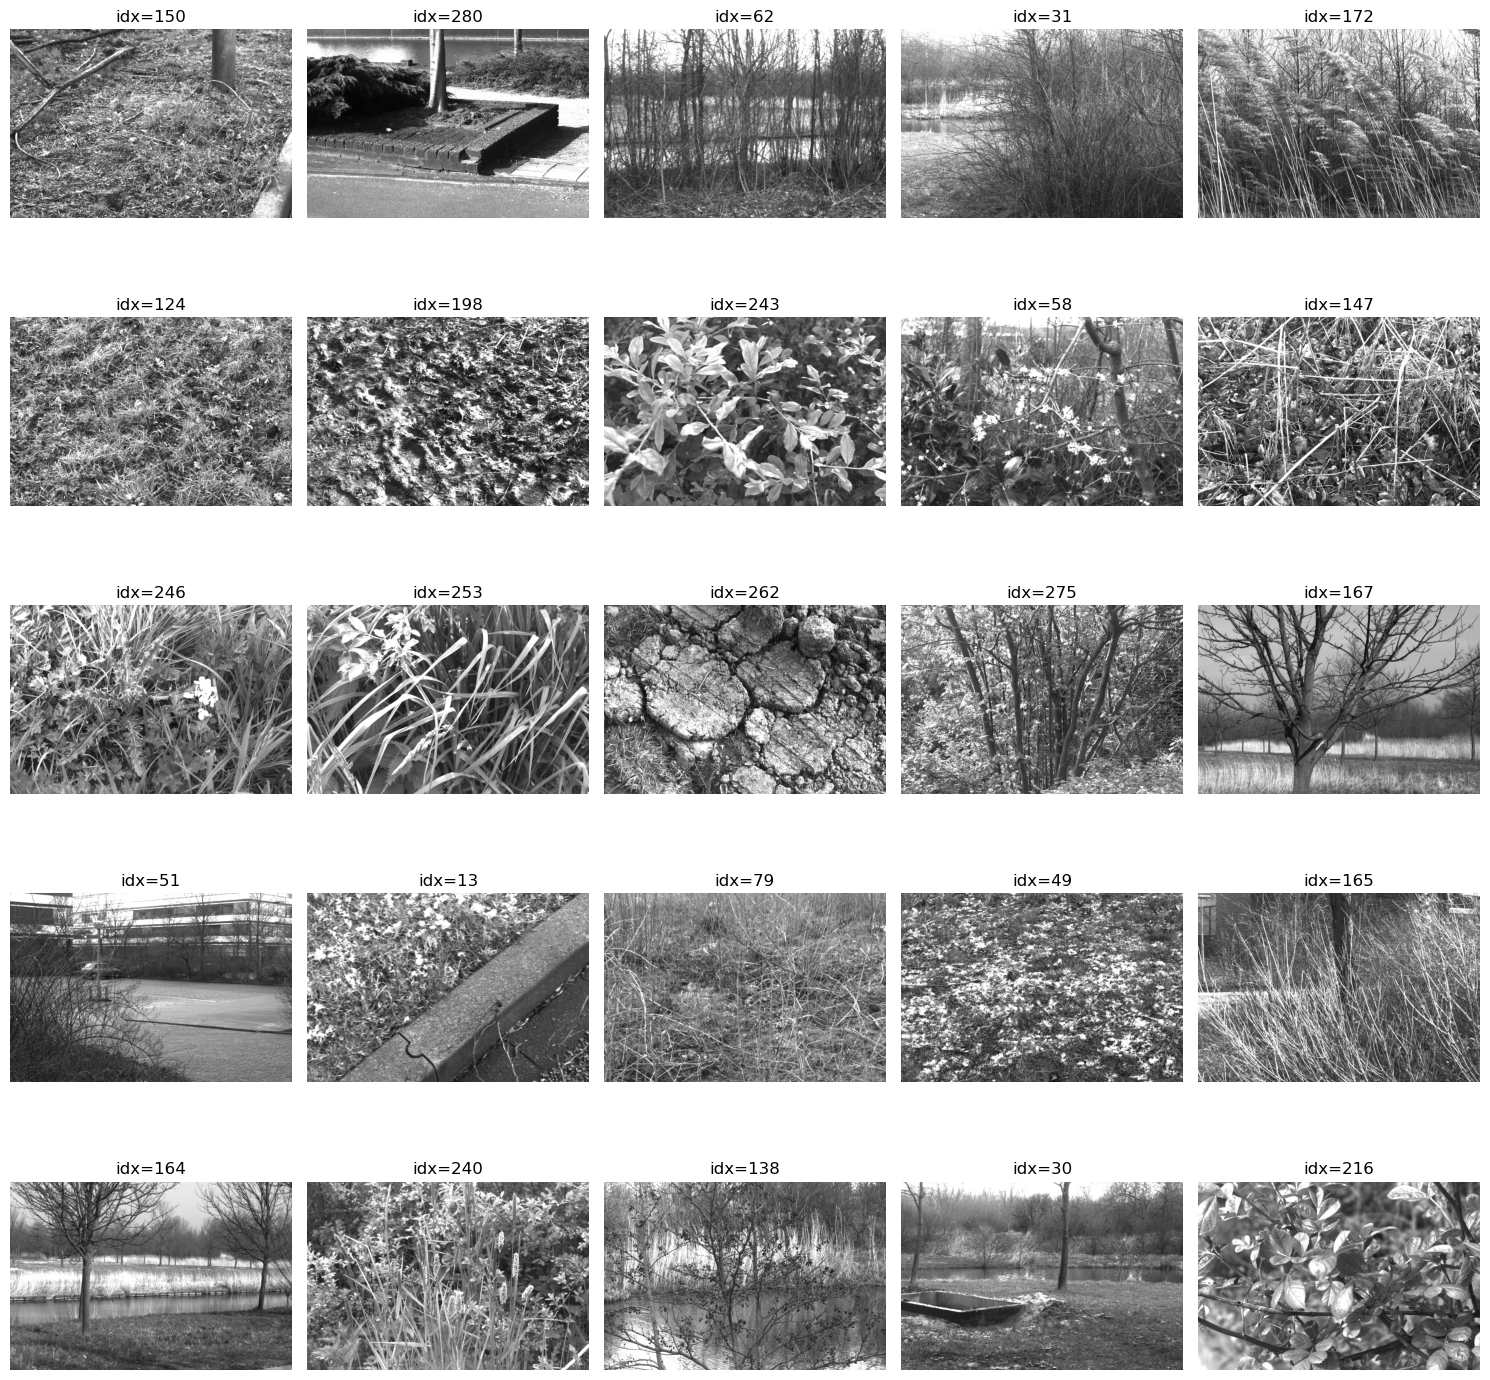

In [9]:
n_rows = 5
n_cols = 5
n_samples = n_rows * n_cols

rng = np.random.default_rng()
image_indices = rng.choice(len(running_images), size=min(n_samples, len(running_images)), replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = np.atleast_2d(axes)

for ax, idx in zip(axes.flat, image_indices):
    ax.imshow(running_images[idx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"idx={idx}")
    ax.axis("off")

for ax in axes.flat[len(image_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

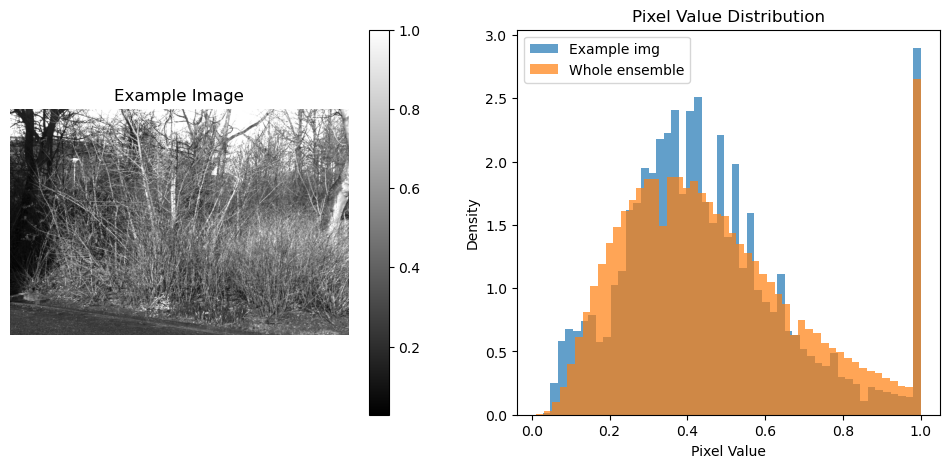

In [7]:
all_imgs = running_images
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im = axes[0].imshow(all_imgs[idx], cmap='gray')
axes[0].set_title("Example Image")
axes[0].axis('off')

axes[1].hist(all_imgs[idx].flatten(), bins=50, density=True, alpha=0.7, label='Example img')
axes[1].hist(all_imgs.flatten(), bins=50, density=True, alpha=0.7, label='Whole ensemble')
plt.colorbar(im, ax=axes[0])
axes[1].set_title("Pixel Value Distribution")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Density")
axes[1].legend()